In [1]:
# ==================================================
#  import Libraries
#===================================================
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#=========================================
# Load data set
#========================================
df = pd.read_csv("iris_cleaned.csv") 
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
142,6.7,3.0,5.2,2.3,virginica
143,6.3,2.5,5.0,1.9,virginica
144,6.5,3.0,5.2,2.0,virginica
145,6.2,3.4,5.4,2.3,virginica


In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = df["species"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)   # setosa=0, versicolor=1, virginica=2

In [5]:
#=================================================
# Train/Test split  Scaling
#=================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# =========================================================
# models train
#==========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.9333333333333333
Decision Tree Accuracy: 0.9333333333333333
Random Forest Accuracy: 0.9666666666666667


In [7]:
#================================================================
# Grid Search
#================================================================
param_grid = {"n_estimators": [50, 100, 200], "max_depth": [None, 3, 5, 10]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best params:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

Best params: {'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9568840579710145


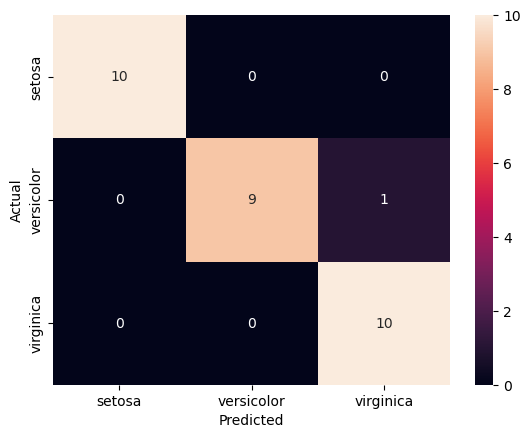

In [9]:
#=================================================
# Confusion Matrix
#=================================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()